# Phase 5 — Baseline & Ensemble Models
Competition: Playground Series S6E7 — Predicting Student Health Risk  
Metric: **Balanced accuracy** (average per-class recall)

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from src.data_prep import load_data, split_data, get_column_types
from src.features import fit_and_save_preprocessor
from src.train import train_logistic, train_random_forest, cross_validate, save_model
from src.evaluate import evaluate_sklearn, plot_confusion_matrix

## 1. Load & split data

In [2]:
train_df, test_df = load_data('../data/raw')
X_train, X_val, y_train, y_val = split_data(train_df)

print('Train size:', X_train.shape)
print('Val size:  ', X_val.shape)

print('\nClass balance (train):')
print(y_train.value_counts(normalize=True).round(3))

Train size: (1600, 11)
Val size:   (400, 11)

Class balance (train):
health_condition
fit          0.369
unhealthy    0.344
at-risk      0.287
Name: proportion, dtype: float64


## 2. Build & fit preprocessing pipeline

In [3]:
numeric_cols, categorical_cols = get_column_types(X_train)
print('Numeric cols:    ', numeric_cols)
print('Categorical cols:', categorical_cols)

preprocessor = fit_and_save_preprocessor(
    X_train, numeric_cols, categorical_cols,
    save_path='../models/preprocessor.pkl'
)

X_train_proc = preprocessor.transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
print('Processed shape:', X_train_proc.shape)

Numeric cols:     ['age', 'height_cm', 'weight_kg', 'bmi', 'sleep_hours', 'physical_activity_hours', 'screen_time_hours']
Categorical cols: ['gender', 'stress_level', 'diet_quality', 'academic_pressure']
Preprocessor saved -> ../models/preprocessor.pkl
Processed shape: (1600, 19)


## 3. Logistic Regression — baseline


-- Logistic Regression --
Balanced accuracy: 0.5937
              precision    recall  f1-score   support

     at-risk       0.66      0.73      0.69       115
         fit       0.65      0.64      0.64       148
   unhealthy       0.45      0.41      0.43       137

    accuracy                           0.59       400
   macro avg       0.58      0.59      0.59       400
weighted avg       0.58      0.59      0.58       400



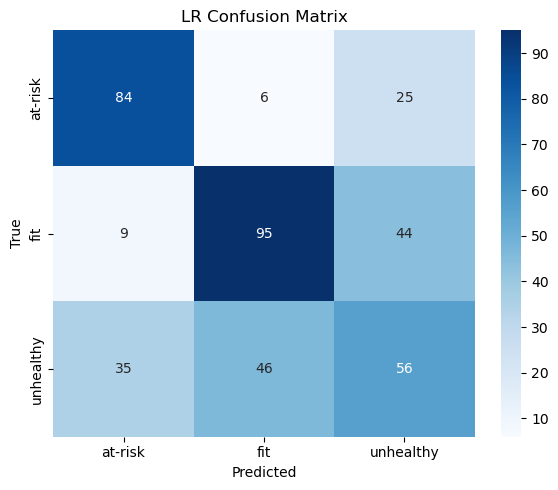

In [4]:
lr = train_logistic(X_train_proc, y_train)
lr_bal_acc, lr_preds = evaluate_sklearn(lr, X_val_proc, y_val, 'Logistic Regression')
plot_confusion_matrix(y_val, lr_preds, lr.classes_, title='LR Confusion Matrix')

## 4. Random Forest with GridSearchCV

Fitting 5 folds for each of 12 candidates, totalling 60 fits


Best RF params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 300}
Best CV balanced accuracy: 0.6583

-- Random Forest (tuned) --
Balanced accuracy: 0.6734
              precision    recall  f1-score   support

     at-risk       0.74      0.81      0.78       115
         fit       0.72      0.73      0.72       148
   unhealthy       0.53      0.48      0.50       137

    accuracy                           0.67       400
   macro avg       0.66      0.67      0.67       400
weighted avg       0.66      0.67      0.66       400



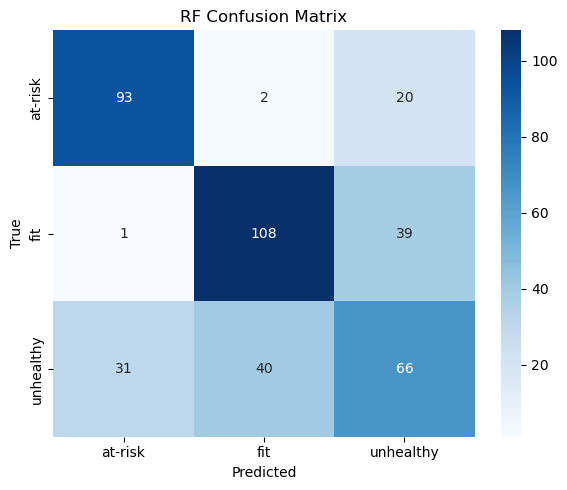

In [5]:
best_rf = train_random_forest(X_train_proc, y_train, cv=5)
rf_bal_acc, rf_preds = evaluate_sklearn(best_rf, X_val_proc, y_val, 'Random Forest (tuned)')
plot_confusion_matrix(y_val, rf_preds, best_rf.classes_, title='RF Confusion Matrix')

## 5. Cross-validate best candidate

In [6]:
cv_scores = cross_validate(best_rf, X_train_proc, y_train, cv=5)
print(f'RF CV balanced accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

CV balanced accuracy: 0.6583 ± 0.0220
RF CV balanced accuracy: 0.6583 ± 0.0220


## 6. Results summary

In [7]:
results = pd.DataFrame([
    {'Model': 'LogisticRegression (balanced)', 'Val balanced_acc': lr_bal_acc, 'CV mean': '-', 'CV std': '-', 'Notes': 'baseline'},
    {'Model': 'RandomForest (tuned, balanced)', 'Val balanced_acc': rf_bal_acc, 'CV mean': round(cv_scores.mean(),4), 'CV std': round(cv_scores.std(),4), 'Notes': str(best_rf.get_params())},
])
print(results.to_markdown(index=False))
results.to_csv('../models/results_so_far.csv', index=False)

| Model                          |   Val balanced_acc | CV mean   | CV std   | Notes                                                                                                                                                                                                                                                                                                                                                                                                                               |
|:-------------------------------|-------------------:|:----------|:---------|:------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## 7. Save best sklearn model so far

In [8]:
# Save whichever is better
best_model = best_rf if rf_bal_acc >= lr_bal_acc else lr
save_model(best_model, '../models/model_final.pkl')
print('Saved model type:', type(best_model).__name__)

Model saved -> ../models/model_final.pkl
Saved model type: RandomForestClassifier
